# HW01 作业答案

姓名：可自行填写  
学号：可自行填写

本 notebook 根据题目要求完成理论计算题与编程题。

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知

$$
a=\begin{bmatrix}2\\-1\\3\end{bmatrix},\quad
b=\begin{bmatrix}1\\4\\-2\end{bmatrix},\quad
A=\begin{bmatrix}1 & 0 & 2\\-1 & 3 & 1\end{bmatrix},\quad
B=\begin{bmatrix}2 & 1\\0 & -1\\3 & 2\end{bmatrix}
$$

1. 向量点积：

$$
a\cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = 2 - 4 - 6 = -8
$$

2. 矩阵乘法：

$$
AB =
\begin{bmatrix}
1 & 0 & 2\\
-1 & 3 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 1\\
0 & -1\\
3 & 2
\end{bmatrix}
=
\begin{bmatrix}
8 & 5\\
1 & -2
\end{bmatrix}
$$

结果矩阵形状为 **2 × 2**。

3. 向量 $a$ 的 Frobenius 范数（即二范数）：

$$
\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{14} \approx 3.741657
$$

In [2]:
import numpy as np

np.random.seed(42)

# 1. 创建随机矩阵 X
X = np.random.randn(3, 4)

# 2. 创建全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算 Z = X @ Y
Z = X @ Y

# 4. 输出指定元素
print("X =\n", X)
print("\nY =\n", Y)
print("\nZ = X @ Y =\n", Z)
print("\nZ 的第一行第二列元素 =", Z[0, 1])
print("Z 的第 2 行所有元素 =", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
print("\nZ 的 Frobenius 范数 =", np.linalg.norm(Z))

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z 的第一行第二列元素 = 2.5291682463487657
Z 的第 2 行所有元素 = [1.87835721 1.87835721]

Z 的 Frobenius 范数 = 4.616873319476864


## 3 概率与统计

### 3.1 理论计算题

设事件：
- $D$：真正患病
- $\bar D$：未患病
- $+$：检测阳性

已知：
- $P(D)=0.001$
- $P(+|D)=0.99$
- $P(+|\bar D)=0.02$

由贝叶斯公式：
$$
P(D|+) = \frac{P(+|D)P(D)}{P(+)}
$$
其中
$$
P(+) = P(+|D)P(D) + P(+|\bar D)P(\bar D)
= 0.99\times0.001 + 0.02\times0.999
= 0.02097
$$

因此：
$$
P(D|+) = \frac{0.99\times0.001}{0.02097}
\approx 0.04721
$$

所以，一个人检测结果为阳性时，他真正患病的概率约为 **4.72%**。


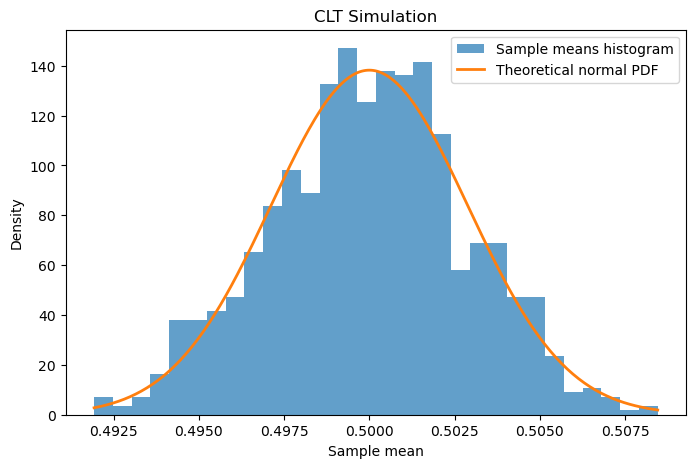

这些均值的实际方差 = 8.275637010510702e-06
理论方差 = 8.333333333333332e-06


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)
n = 10000
m = 1000

# 1. 生成样本均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 2. 绘制直方图并叠加理论正态分布曲线
mu_theory = 0.5
sigma_theory = math.sqrt((1/12) / n)

x = np.linspace(means.min(), means.max(), 300)
pdf = (1 / (sigma_theory * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x - mu_theory) / sigma_theory) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, label="Sample means histogram")
plt.plot(x, pdf, linewidth=2, label="Theoretical normal PDF")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("CLT Simulation")
plt.legend()
plt.show()

# 3. 计算实际方差
print("这些均值的实际方差 =", np.var(means))
print("理论方差 =", (1/12) / n)

## 4 导数、反向传播和复杂度

### 4.1 理论计算题

给定
$$
z=(w_1x_1+w_2x_2-y)^2
$$
其中 $x_1=2, x_2=1, y=3$。

设
$$
u = w_1x_1+w_2x_2-y
$$
则
$$
z=u^2
$$

根据链式法则：
$$
\frac{\partial z}{\partial w_1} = 2u\cdot \frac{\partial u}{\partial w_1}
=2(w_1x_1+w_2x_2-y)x_1
$$
$$
\frac{\partial z}{\partial w_2} = 2u\cdot \frac{\partial u}{\partial w_2}
=2(w_1x_1+w_2x_2-y)x_2
$$

代入 $x_1=2, x_2=1, y=3$ 可得：
$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3)
$$
$$
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3)
$$

当 $w_1=0.5, w_2=1$ 时：
$$
2w_1+w_2-3 = 2\times0.5+1-3 = -1
$$

所以：
$$
\frac{\partial z}{\partial w_1} = 4\times(-1) = -4
$$
$$
\frac{\partial z}{\partial w_2} = 2\times(-1) = -2
$$


In [5]:
import torch

# 1. 定义前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向计算结果：")
print("a =", a)
print("b =", b)
print("L =", L)

# 2. 手动反向传播
# L = b^2, dL/db = 2b
# b = a + w2, db/da = 1, db/dw2 = 1
# a = x*w1, da/dw1 = x

dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * x

print("\n手动计算梯度：")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# 3. 使用自动微分验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\n自动微分结果：")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())

前向计算结果：
a = 3.0
b = 3.5
L = 12.25

手动计算梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0


## 5 线性方法、基础优化和 Softmax 回归

### 5.1 理论计算题

线性回归模型为：
$$
\hat y_i = wx_i + b
$$
均方误差损失为：
$$
L = \frac{1}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))^2
$$

对 $w$ 求偏导：
$$
\frac{\partial L}{\partial w}
= \frac{1}{n}\sum_{i=1}^n 2(y_i-(wx_i+b))(-x_i)
= -\frac{2}{n}\sum_{i=1}^n x_i(y_i-(wx_i+b))
$$

对 $b$ 求偏导：
$$
\frac{\partial L}{\partial b}
= \frac{1}{n}\sum_{i=1}^n 2(y_i-(wx_i+b))(-1)
= -\frac{2}{n}\sum_{i=1}^n (y_i-(wx_i+b))
$$

因此：
$$
\boxed{\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^n x_i(y_i-(wx_i+b))}
$$
$$
\boxed{\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i-(wx_i+b))}
$$


测试集准确率 = 0.9527777777777777


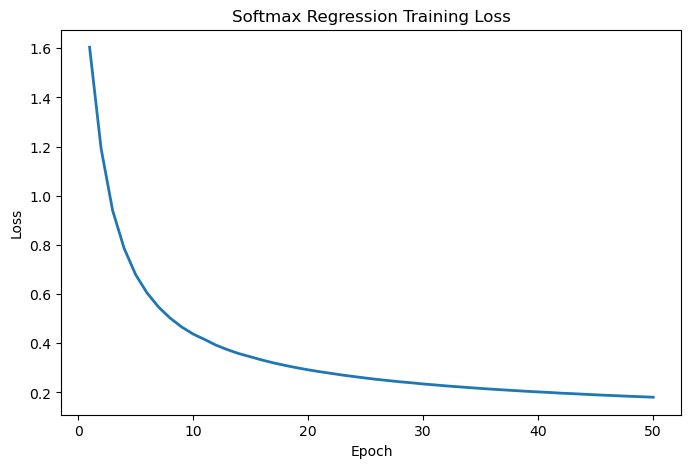

In [6]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0
y = digits.target

# 2. one-hot 编码
num_classes = 10
Y = np.eye(num_classes)[y]

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 实现 softmax 与交叉熵
def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(logits)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 4. 小批量 SGD 训练
n_features = X_train.shape[1]
W = np.zeros((n_features, num_classes))
b = np.zeros((1, num_classes))

batch_size = 32
lr = 0.1
epochs = 50
n_train = X_train.shape[0]

loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n_train)
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for i in range(0, n_train, batch_size):
        xb = X_train_shuffled[i:i+batch_size]
        yb = Y_train_shuffled[i:i+batch_size]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / len(xb)
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    train_loss = cross_entropy(Y_train, softmax(X_train @ W + b))
    loss_history.append(train_loss)

# 5. 测试集准确率
test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)

print("测试集准确率 =", test_acc)

# 画损失曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Softmax Regression Training Loss")
plt.show()

## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于 $N(\mu,\sigma^2)$，则单个样本的密度为：
$$
f(x_i;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

1. 似然函数：
$$
L(\mu,\sigma^2)=\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$
整理得：
$$
L(\mu,\sigma^2)=(2\pi\sigma^2)^{-n/2}
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right)
$$

2. 对数似然函数：
$$
\ell(\mu,\sigma^2)=\ln L
= -\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln\sigma^2
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

对 $\mu$ 求偏导：
$$
\frac{\partial \ell}{\partial \mu}
= \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$
令其等于 0：
$$
\sum_{i=1}^{n}(x_i-\mu)=0
\Rightarrow n\mu=\sum_{i=1}^{n}x_i
\Rightarrow
\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

3. 对 $\sigma^2$ 求偏导：
$$
\frac{\partial \ell}{\partial \sigma^2}
= -\frac{n}{2\sigma^2}
+ \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$
令其等于 0，并代入 $\hat\mu$：
$$
-\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\hat\mu)^2 = 0
$$
两边乘以 $2(\sigma^2)^2$：
$$
-n\sigma^2 + \sum_{i=1}^{n}(x_i-\hat\mu)^2 = 0
$$
所以：
$$
\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$


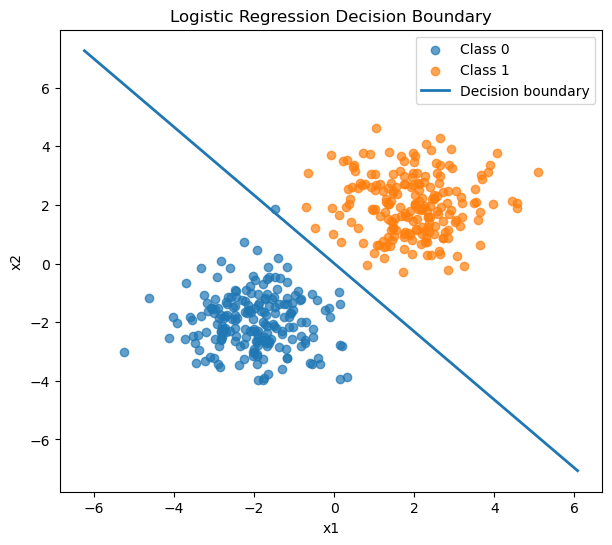

测试集准确率 = 1.0
训练完成后的参数：
w = [2.1698258 1.8662945]
b = -0.004148600563620097


In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. 生成线性可分数据
n_per_class = 200
class0 = np.random.randn(n_per_class, 2) + np.array([-2, -2])
class1 = np.random.randn(n_per_class, 2) + np.array([2, 2])

X = np.vstack([class0, class1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

# 2. sigmoid 与二元交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 3. 梯度下降学习参数
w = np.zeros(2)
b = 0.0
lr = 0.1
num_iters = 1000

for i in range(num_iters):
    z = X @ w + b
    y_pred = sigmoid(z)

    dw = X.T @ (y_pred - y) / len(X)
    db = np.mean(y_pred - y)

    w -= lr * dw
    b -= lr * db

# 4. 绘制决策边界
plt.figure(figsize=(7, 6))
plt.scatter(class0[:, 0], class0[:, 1], alpha=0.7, label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], alpha=0.7, label="Class 1")

x1_vals = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
x2_vals = -(w[0] * x1_vals + b) / w[1]
plt.plot(x1_vals, x2_vals, linewidth=2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# 5. 在测试集上评估
test0 = np.random.randn(50, 2) + np.array([-2, -2])
test1 = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack([test0, test1])
y_test = np.hstack([np.zeros(50), np.ones(50)])

test_pred = (sigmoid(X_test @ w + b) >= 0.5).astype(int)
acc = np.mean(test_pred == y_test)

print("测试集准确率 =", acc)
print("训练完成后的参数：")
print("w =", w)
print("b =", b)